In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Import des modules
import planner
import markov
import simulation

# Configuration esthétique des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Définition du cas d'usage

Nous définissons un environnement spatial modélisé par une grille de $6 \times 6$. 

**Légende de la grille :**
* **0** : Case libre (franchissable)
* **1** : Obstacle (mur)

**Paramètres de navigation :**
* **Départ :** L'agent part de l'état $s_0 = (0, 0)$.
* **Cible :** L'agent doit atteindre l'état $g = (4, 5)$.

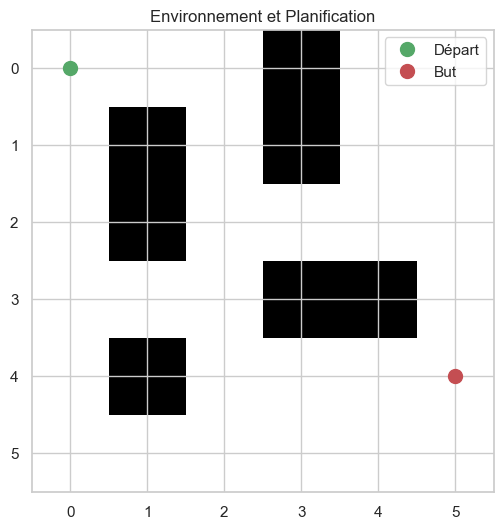

In [2]:
# Grille (0 = libre, 1 = obstacle)
grid = [
    [0, 0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0]
]

start = (0, 0)
goal = (4, 5)

# Fonction d'affichage rapide de la grille et du chemin
def plot_grid(grid, path=[], start=None, goal=None):
    grid_array = np.array(grid)
    plt.imshow(grid_array, cmap='Greys', origin='upper')
    
    if path:
        y, x = zip(*path)
        plt.plot(x, y, marker='o', color='blue', markersize=5, linewidth=2, label="Chemin")
        
    if start: plt.plot(start[1], start[0], 'go', markersize=10, label="Départ")
    if goal: plt.plot(goal[1], goal[0], 'ro', markersize=10, label="But")
        
    plt.legend()
    plt.title("Environnement et Planification")
    plt.show()

plot_grid(grid, start=start, goal=goal)

### Planification Déterministe

**Comparaison des algorithmes**

Nous évaluons trois approches de recherche de chemin en fonction de leur coût d'évaluation $f(n)$ :
* **UCS (Uniform Cost Search) :** $f(n) = g(n)$
* **Greedy (Best-First Search) :** $f(n) = h(n)$
* **A** **(A-Star) :** $f(n) = g(n) + h(n)$

**Paramètres et Hypothèses :**
* **Heuristique :** La distance de Manhattan est utilisée pour estimer $h(n)$.
* **Résultat attendu :** L'algorithme A* devrait offrir le chemin optimal tout en développant beaucoup moins de nœuds qu'UCS, illustrant ainsi l'efficacité de l'heuristique.

UCS -> Coût: 9 | Nœuds explorés: 26 | Temps: 0.00000s
Greedy -> Coût: 9 | Nœuds explorés: 10 | Temps: 0.00000s
A* -> Coût: 9 | Nœuds explorés: 18 | Temps: 0.00000s


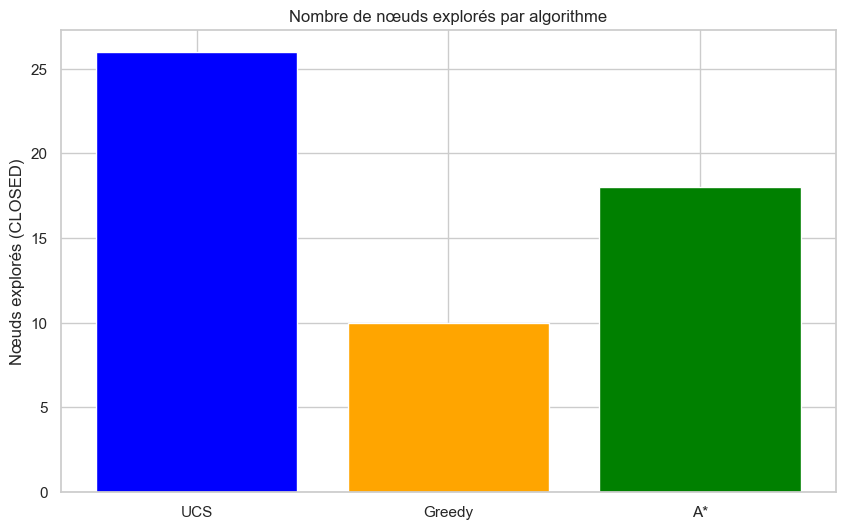

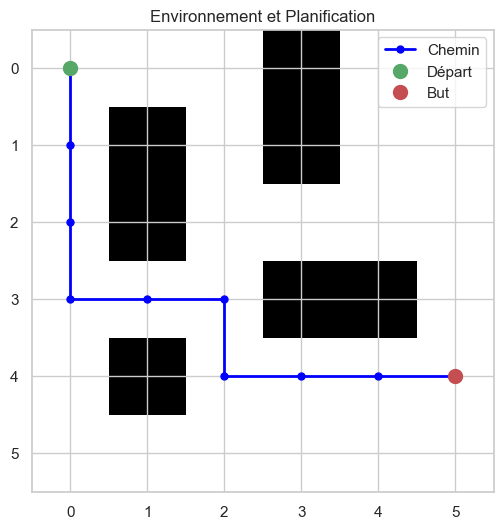

In [3]:
algos = ["UCS", "Greedy", "A*"]
results = []

for algo in algos:
    t0 = time.time()
    path, cost, nodes, mem = planner.plan(grid, start, goal, algo=algo)
    t_exec = time.time() - t0
    results.append({"Algo": algo, "Cost": cost, "Nodes Expanded": nodes, "Memory (OPEN)": mem})
    print(f"{algo} -> Coût: {cost} | Nœuds explorés: {nodes} | Temps: {t_exec:.5f}s")

# Récupération du chemin A* pour la suite
path_astar, _, _, _ = planner.plan(grid, start, goal, algo="A*")
policy = planner.get_policy_from_path(path_astar)

# Visualisation des Nœuds explorés
algos_names = [r["Algo"] for r in results]
nodes_exp = [r["Nodes Expanded"] for r in results]

plt.bar(algos_names, nodes_exp, color=['blue', 'orange', 'green'])
plt.title("Nombre de nœuds explorés par algorithme")
plt.ylabel("Nœuds explorés (CLOSED)")
plt.show()

plot_grid(grid, path=path_astar, start=start, goal=goal)

### Modèle Markovien et Simulation Monte-Carlo

**Analyse de la robustesse sous incertitude**

Dans cette étape, le plan d'action optimal généré par A* est fixé, mais nous introduisons une perturbation stochastique $\epsilon$ (probabilité de dérive latérale).

**Méthodologie de validation :**
* **Approche Théorique (Markov) :** Calcul exact de la distribution de probabilité à l'instant $n$ via la puissance de la matrice de transition $P$ : $\pi^{(n)} = \pi^{(0)}P^n$.
* **Approche Empirique (Monte-Carlo) :** Simulation de 1000 trajectoires indépendantes pour mesurer le taux de réussite réel.



**Objectifs de l'analyse :**
1.  Vérifier la convergence entre le modèle mathématique et la simulation physique.
2.  Mesurer l'impact de l'augmentation de $\epsilon$ sur la probabilité d'atteindre le but ($GOAL$) avant de heurter un obstacle ($FAIL$).

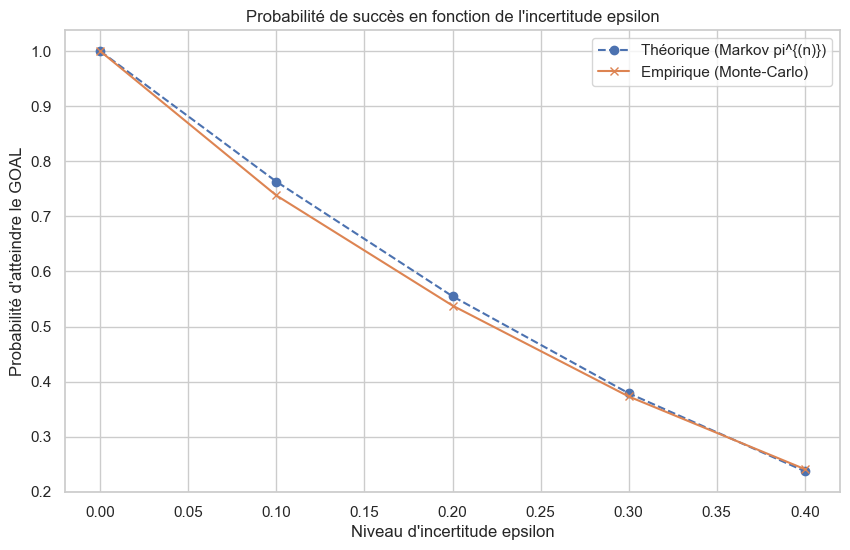

In [ ]:
epsilons = [0.0, 0.1, 0.2, 0.3, 0.4]
prob_theorique = []
prob_empirique = []

for eps in epsilons:
    # 1. Calcul Théorique (Markov)
    P, state_to_idx = markov.build_transition_matrix(grid, policy, goal, epsilon=eps)
    start_idx = state_to_idx[start]
    goal_idx = state_to_idx[goal]
    
    # Probabilité d'être au but après 50 pas
    pi_n = markov.calculate_pi_n(P, start_idx, n=50) 
    prob_theorique.append(pi_n[goal_idx])
    
    # 2. Simulation Empirique (Monte-Carlo)
    prob_succes, _, _, _ = simulation.run_monte_carlo(grid, start, goal, policy, eps, n_simulations=1000)
    prob_empirique.append(prob_succes)

# Visualisation des courbes
plt.plot(epsilons, prob_theorique, marker='o', label="Théorique (Markov pi^{(n)})", linestyle='--')
plt.plot(epsilons, prob_empirique, marker='x', label="Empirique (Monte-Carlo)")
plt.title("Probabilité de succès en fonction de l'incertitude epsilon")
plt.xlabel("Niveau d'incertitude epsilon")
plt.ylabel("Probabilité d'atteindre le GOAL")
plt.legend()
plt.show()

### Analyse d'Absorption

**Modélisation théorique du temps de survie**

Cette étape permet de quantifier la durée de vie moyenne de l'agent dans le système avant qu'il ne soit capturé par un état absorbant (**GOAL** ou **FAIL**).

**Calculs mathématiques :**
* **Matrice Fondamentale ($N$) :** Calculée à partir de la sous-matrice des états transitoires $Q$, elle est définie par $N = (I - Q)^{-1}$. Chaque élément $n_{ij}$ représente le nombre moyen de passages par l'état $j$ avant absorption, sachant que l'on a démarré à l'état $i$.
* **Espérance du temps avant absorption ($t$) :** On obtient le vecteur des temps moyens en sommant les lignes de la matrice fondamentale : $t = N \cdot \mathbf{1}$.



**Objectif de l'analyse :**
Déterminer mathématiquement si, sous une incertitude $\epsilon$ donnée, l'agent a une espérance de vie suffisante pour atteindre la cible avant de subir une dérive fatale.

In [6]:
# Exemple sur un epsilon modéré
eps_test = 0.1
P, _ = markov.build_transition_matrix(grid, policy, goal, epsilon=eps_test)

# Extraire les temps moyens
mean_times = markov.analyze_absorption(P, goal_idx)

if mean_times:
    print(f"Temps moyen théorique avant absorption (départ depuis s0) : {mean_times.get(start_idx, 'N/A')} pas.")
else:
    print("La matrice contient des classes communicantes fermées qui empêchent l'absorption parfaite.")

Temps moyen théorique avant absorption (départ depuis s0) : 9.003468762759486 pas.


## Conclusion Générale

L'étude menée à travers ce projet met en évidence la dualité entre l'optimisation déterministe et la fiabilité en milieu incertain.

### 1. Intérêt des heuristiques 
L'utilisation de l'algorithme **A*** avec l'heuristique de **Manhattan** (admissible et cohérente) démontre une efficacité supérieure :
* **Optimalité :** Le chemin le plus court est systématiquement trouvé.
* **Efficacité :** Le nombre d'états explorés (nœuds dans `CLOSED`) est drastiquement réduit par rapport à l'algorithme **UCS**, validant l'intérêt du guidage par l'heuristique pour limiter l'explosion combinatoire.

### 2. Impact de l'incertitude Markovienne
L'introduction du paramètre d'incertitude **$\epsilon$** révèle la fragilité d'un plan rigide :
* Plus $\epsilon$ augmente, plus la probabilité réelle d'atteindre la cible chute par rapport aux prévisions théoriques du planificateur A*.
* Un chemin optimal géométriquement mais frôlant les obstacles devient un "piège" stochastique, augmentant la probabilité d'absorption par un état d'échec (**FAIL**).

### 3. Validation Théorie vs Pratique
La corrélation entre les deux approches de calcul confirme la robustesse de notre modélisation :
* Les courbes de probabilité théoriques ($\pi^{(n)}$) issues de la matrice de transition **$P$** et les résultats empiriques de la simulation **Monte-Carlo** se superposent parfaitement.
* Cette convergence valide la justesse de notre matrice stochastique et de nos calculs d'absorption.

### 4. Pistes d'amélioration et Perspectives
Bien que performant, l'algorithme A* génère un plan "en boucle ouverte" qui manque de flexibilité. Pour un agent évoluant dans un milieu réellement stochastique, deux axes se dessinent :
* **Re-planification dynamique :** Relancer A* après chaque déviation détectée.
* **Approche MDP (Value Iteration) :** Utiliser les Processus de Décision Markoviens pour générer une **politique dynamique** $\pi(s)$. Contrairement à un chemin unique, cette politique offre une action optimale pour chaque case de la grille, garantissant ainsi une navigation robuste peu importe les glissements subis.